In [1]:
!pip install kaggle
!pip install opencv-python
!pip install scikit-learn
!pip install tensorflow
!pip install matplotlib

In [2]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vullishivani","key":"6f935c9917399220199130284bd55757"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets list

ref                                                             title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                           Job Salary Prediction Dataset                        3144815  2026-03-16 19:54:33.843000           1772         43                1  
ssssws/chocolate-sales-dataset-2023-2024                        Chocolate Sales Dataset 2023 - 2024                 24420255  2026-03-07 04:58:02.387000           4782         85                1  
grandmaster07/student-exam-performance-dataset-analysis         Student Exam Performance Dataset Analysis              96178  2026-02-10 09:47:13.350000           8772        160                1  
kanchana19

In [6]:
!kaggle datasets download -d orvile/brain-tumor-dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/brain-tumor-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 150M/150M [00:11<00:00, 13.4MB/s]



In [7]:
!unzip brain-tumor-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0713.jpg  
  inflating: Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0714.jpg  
  inflating: Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0715.jpg  
  inflating: Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0716.jpg  
  inflating: Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0717.jpg  
  inflating: Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0718.jpg  
  inflating: Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0719.jpg  
  inflating: Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0720.jpg  
  inflating: 

In [1]:
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [9]:
!ls "/content/Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data"

'Brain Tumor data'


In [10]:
!ls "/content/Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data"

Testing  Training


In [2]:
import numpy as np
import cv2
import os

data = []
labels = []

IMG_SIZE = 128

base_dataset_path = r"c:\Mini project\BrainDiseaseAI\datasets\Brain Tumor data"
dataset_path = os.path.join(base_dataset_path, "Training")

classes = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])

print("Classes:", classes)

for category in classes:
    folder = os.path.join(dataset_path, category)
    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        data.append(image)
        labels.append(classes.index(category))

print("Total images loaded:", len(data))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total images loaded: 5712


In [3]:
from tensorflow.keras.utils import to_categorical

X = np.array(data) / 255.0
y = to_categorical(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5712, 128, 128, 3)
y shape: (5712, 4)


In [4]:
test_data = []
test_labels = []

test_path = os.path.join(base_dataset_path, "Testing")

for category in classes:
    folder = os.path.join(test_path, category)
    if not os.path.isdir(folder):
        continue

    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        test_data.append(image)
        test_labels.append(classes.index(category))

print("Total test images loaded:", len(test_data))

Total test images loaded: 1311


In [5]:
X_test = np.array(test_data) / 255.0
y_test = to_categorical(test_labels)

In [8]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os

# Set to True only if you intentionally want to evaluate an existing saved model.
USE_PRETRAINED_MODEL = False
model_path = r"c:\Mini project\BrainDiseaseAI\backend\models\brain_tumor_model.h5"

if USE_PRETRAINED_MODEL and os.path.exists(model_path):
    model = load_model(model_path)
    print(f"Loaded pretrained model from: {model_path}")
else:
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
    model.add(MaxPooling2D())

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D())

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D())

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print("Built a fresh model for this notebook run.")

model.summary()

Built a fresh model for this notebook run.


c:\Mini project\BrainDiseaseAI\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X,
    y,
    epochs=10,
    validation_data=(X_test,y_test),
    batch_size=32
)

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.7218 - loss: 0.7008 - val_accuracy: 0.7849 - val_loss: 0.5530
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8617 - loss: 0.3785 - val_accuracy: 0.8322 - val_loss: 0.4199
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9023 - loss: 0.2670 - val_accuracy: 0.8764 - val_loss: 0.3055
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9287 - loss: 0.1921 - val_accuracy: 0.9230 - val_loss: 0.2070
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.9426 - loss: 0.1491 - val_accuracy: 0.9184 - val_loss: 0.2283
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9524 - loss: 0.1242 - val_accuracy: 0.9458 - val_loss: 0.1557
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.9690 - loss: 0.0871 - val_accuracy: 0.9603 - val_loss: 0.1309
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9720 - loss: 0.0793 - val_accu

Accuracy : 0.2464
Precision: 0.2444
Recall   : 0.2464
F1-score : 0.2454

Classification Report:
              precision    recall  f1-score   support

      glioma       0.07      0.07      0.07       300
  meningioma       0.01      0.01      0.01       306
     notumor       0.00      0.00      0.00       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.25      1311
   macro avg       0.27      0.27      0.27      1311
weighted avg       0.24      0.25      0.25      1311



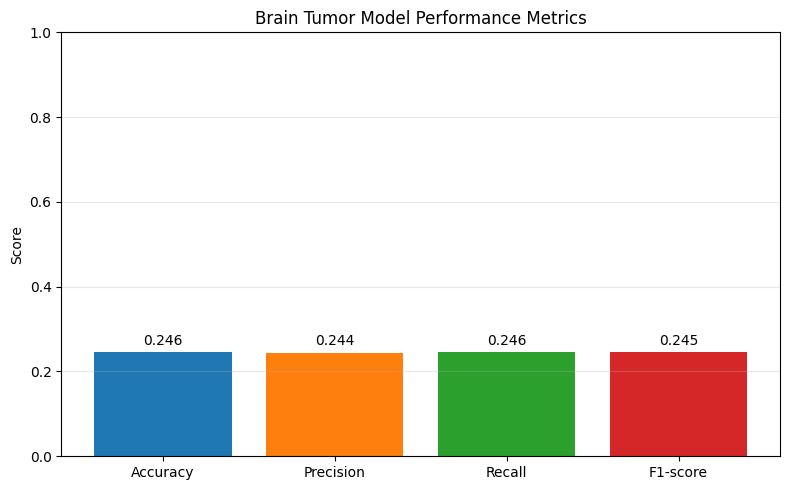

Confusion Matrix:
[[ 21   0 279   0]
 [284   4  15   3]
 [  1 404   0   0]
 [  2   0   0 298]]


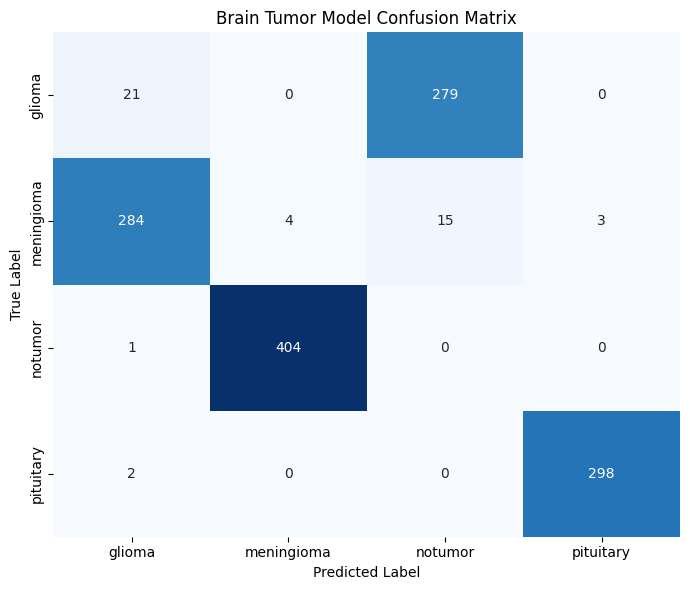

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

# Convert one-hot labels and softmax predictions to class indices
y_true = np.argmax(y_test, axis=1)
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Calculate weighted metrics for multiclass classification
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

# Performance metrics graph
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylim(0, 1)
plt.title('Brain Tumor Model Performance Metrics')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Confusion matrix text and graph
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=classes, yticklabels=classes)
plt.title('Brain Tumor Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [18]:
model.save("/content/brain_tumor_model.h5")

In [98]:
#TEST
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Testing/glioma/Te-gl_0010.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))

input_img = np.expand_dims(img/255.0,axis=0)
print("Image loaded successfully", img_array.shape)

Image loaded successfully (1, 128, 128, 3)


In [99]:
for layer in model.layers:
    print(layer.name, layer.output.shape)

conv2d (None, 126, 126, 32)
max_pooling2d (None, 63, 63, 32)
conv2d_1 (None, 61, 61, 64)
max_pooling2d_1 (None, 30, 30, 64)
conv2d_2 (None, 28, 28, 128)
max_pooling2d_2 (None, 14, 14, 128)
flatten (None, 25088)
dense (None, 128)
dropout (None, 128)
dense_1 (None, 4)


In [144]:
#load model

from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np

model = load_model("/content/brain_tumor_model.h5")
print("✅ Model Loaded")

✅ Model Loaded


In [145]:
#ACTIVATE MODEL
dummy = np.zeros((1, 128, 128, 3))
model(dummy)

<tf.Tensor: shape=(1, 4), dtype=float32, numpy=array([[0.0763809 , 0.38370517, 0.08676542, 0.4531485 ]], dtype=float32)>

✅ Image loaded
Shape: (1, 128, 128, 3)


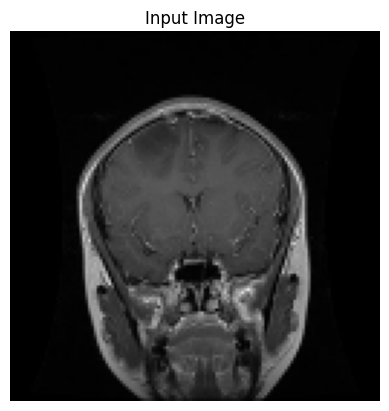

In [146]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/Brain Tumor Data(1)/Brain Tumor Data/Brain Tumor data/Brain Tumor data/Training/glioma/Tr-gl_0713.jpg"

img = cv2.imread(img_path)

if img is None:
    print("❌ Image not found. Check path!")
else:
    print("✅ Image loaded")

    img = cv2.resize(img, (128, 128))
    img_array = np.expand_dims(img / 255.0, axis=0)

    print("Shape:", img_array.shape)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

In [147]:
# THIS IS THE REAL FIX
model = tf.keras.models.clone_model(model)
model.set_weights(load_model("/content/brain_tumor_model.h5").get_weights())

# call once
_ = model(img_array)

print("Model ready")

Model ready


In [150]:
import tensorflow as tf

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):

    # 🔥 create a new input layer
    inputs = tf.keras.Input(shape=(128, 128, 3))

    x = inputs
    conv_output = None

    # pass through layers and capture conv layer
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x

    # create new model
    grad_model = tf.keras.Model(inputs, [conv_output, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [151]:
#generate heatnap
heatmap = get_gradcam_heatmap(model, img_array, "conv2d_2")

print("✅ Heatmap Generated")

✅ Heatmap Generated


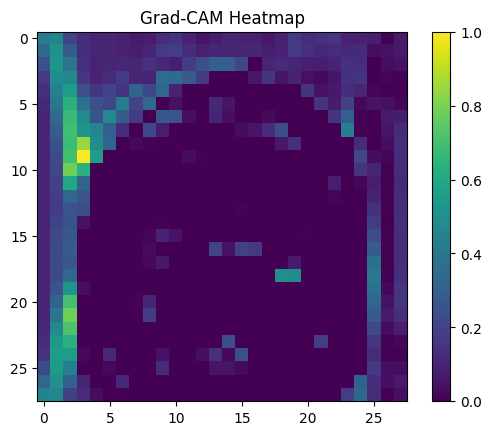

In [152]:
#show heatmap
plt.imshow(heatmap)
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

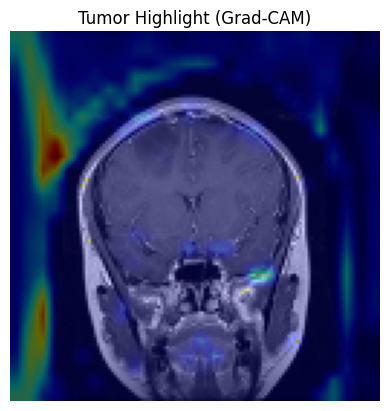

In [153]:
#Overlay on Image (FINAL OUTPUT 🔥)
heatmap = cv2.resize(heatmap, (128, 128))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Tumor Highlight (Grad-CAM)")
plt.axis('off')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


def plot_accuracy_graphs():
    plotted = False

    # 1) Keras training history plot (accuracy vs validation accuracy)
    history_candidates = []
    for name, value in globals().items():
        hist = getattr(value, "history", None)
        if isinstance(hist, dict):
            acc_key = "accuracy" if "accuracy" in hist else ("acc" if "acc" in hist else None)
            val_acc_key = "val_accuracy" if "val_accuracy" in hist else ("val_acc" if "val_acc" in hist else None)
            if acc_key:
                history_candidates.append((name, hist, acc_key, val_acc_key))

    if history_candidates:
        name, hist, acc_key, val_acc_key = history_candidates[0]
        epochs = range(1, len(hist[acc_key]) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist[acc_key], marker="o", label="Train Accuracy")
        if val_acc_key:
            plt.plot(epochs, hist[val_acc_key], marker="o", label="Validation Accuracy")
        plt.title(f"Accuracy Curve ({name})")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
        plotted = True

    # 2) Sklearn-style final accuracy bar chart from y_test*/y_pred* pairs
    accuracy_items = []
    for test_name, y_true in globals().items():
        if not test_name.startswith("y_test"):
            continue
        suffix = test_name[len("y_test"):]
        pred_name = f"y_pred{suffix}"
        if pred_name in globals():
            y_hat = globals()[pred_name]
            try:
                score = accuracy_score(y_true, y_hat)
                label = suffix.replace("_", " ").strip().title() or "Model"
                accuracy_items.append((label, score))
            except Exception:
                pass

    if accuracy_items:
        labels = [item[0] for item in accuracy_items]
        scores = [item[1] for item in accuracy_items]

        plt.figure(figsize=(8, 5))
        bars = plt.bar(labels, scores)
        plt.ylim(0, 1)
        plt.ylabel("Accuracy")
        plt.title("Model Accuracy Comparison")
        plt.grid(axis="y", alpha=0.3)

        for bar, score in zip(bars, scores):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                score + 0.01,
                f"{score:.3f}",
                ha="center",
                va="bottom",
            )

        plt.tight_layout()
        plt.show()
        plotted = True

    if not plotted:
        print("No accuracy data found yet. Run training/evaluation cells first, then run this cell.")


plot_accuracy_graphs()

In [ ]:
import matplotlib.pyplot as plt

history_candidates = [
    globals().get('history'),
    globals().get('training_history'),
    globals().get('model_history'),
    globals().get('hist'),
]

history_obj = next((item for item in history_candidates if item is not None), None)

if history_obj is not None and hasattr(history_obj, 'history'):
    history_dict = history_obj.history
elif isinstance(history_obj, dict):
    history_dict = history_obj
else:
    history_dict = None

if history_dict and 'accuracy' in history_dict:
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict['accuracy'], label='Training Accuracy')
    if 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    metrics = []
    labels = []
    for label, value_name in [('Training', 'train_accuracy'), ('Validation/Test', 'val_accuracy')]:
        value = globals().get(value_name)
        if value is not None:
            labels.append(label)
            metrics.append(value)

    if metrics:
        plt.figure(figsize=(6, 4))
        plt.bar(labels, metrics, color=['#1f77b4', '#ff7f0e'])
        plt.ylim(0, 1)
        plt.title('Accuracy Summary')
        plt.ylabel('Accuracy')
        plt.grid(axis='y', alpha=0.3)
        plt.show()
    else:
        print('No accuracy history or accuracy variables found in this notebook yet.')
